In [1]:
import zipfile
import os
import numpy as np
import glob
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import geopandas as gpd

zip_path = "/Users/martingomez/Desktop/prepdatos.zip"
extract_path = "/Users/martingomez/Desktop/shared/prepdatos"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Archivos extraídos en:", extract_path)

Archivos extraídos en: /Users/martingomez/Desktop/shared/prepdatos


In [2]:
base_path = "/Users/martingomez/Desktop/shared/prepdatos"

census_files = glob.glob(os.path.join(base_path, "census_team*.csv"))
eno_files    = glob.glob(os.path.join(base_path, "eno_team*.csv"))
grd_files    = glob.glob(os.path.join(base_path, "grd_team*.csv"))

print("Census:", len(census_files))
print("ENO:", len(eno_files))
print("GRD:", len(grd_files))

census_master = pd.concat([pd.read_csv(f) for f in census_files], ignore_index=True)
eno_master    = pd.concat([pd.read_csv(f) for f in eno_files], ignore_index=True)
grd_master    = pd.concat([pd.read_csv(f) for f in grd_files], ignore_index=True)

for d in [census_master, eno_master, grd_master]:
    d.columns = d.columns.str.strip()
    d["codigo_comuna"] = pd.to_numeric(d["codigo_comuna"], errors="coerce")

print("Census master:", census_master.shape)
print("ENO master:", eno_master.shape)
print("GRD master:", grd_master.shape)

Census: 21
ENO: 21
GRD: 21
Census master: (54, 13)
ENO master: (54, 8)
GRD master: (54, 13)


In [3]:
print(census_master[["codigo_comuna", "nombre_comuna"]].head())
print(eno_master[["codigo_comuna", "nombre_comuna"]].head())
print(grd_master[["codigo_comuna", "nombre_comuna"]].head())

   codigo_comuna nombre_comuna
0          13110    La Florida
1          13122     Peñalolén
2          13605      Peñaflor
3          13114    LAS CONDES
4          13503      CURACAVÍ
   codigo_comuna     nombre_comuna
0          13102         Cerrillos
1          13105  Estación Central
2          13302             Lampa
3          13120             Ñuñoa
4          13129       San Joaquín
   codigo_comuna nombre_comuna
0          13101      Santiago
1          13502         Alhué
2          13602      El Monte
3          13107    Huechuraba
4          13112    La Pintana


In [4]:
df = census_master.merge(
    eno_master,
    on=["codigo_comuna", "nombre_comuna"],
    how="outer",
    indicator="merge_eno"
)

df = df.merge(
    grd_master,
    on=["codigo_comuna", "nombre_comuna"],
    how="outer",
    indicator="merge_grd"
)

print("Shape final:", df.shape)
df.head()

Shape final: (54, 32)


,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,...,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k,merge_grd
0,5101,Valparaíso,284938.0,272618.0,12320.0,4.320000,36.8,30.1,11.400000,11.900000,...,1639,6.780000,5.600000,5.700000,4.900000,1.920000,2.840000,Embarazo y parto | Enfermedades circulatorias ...,848.61000,both
1,5102,Casablanca,29876.0,27607.0,2269.0,7.590000,34.5,28.7,10.800000,10.300000,...,171,8.010000,4.800000,4.900000,4.100000,1.780000,2.150000,Embarazo y parto | Enfermedades digestivas | E...,714.29000,both
2,13101,Santiago,5806.0,258429.0,176956.0,3047.812608,35.0,34.0,14.421518,13.805328,...,19265,35.072548,6.682745,7.682129,4.817208,1.615485,2.799978,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A) ...",94607.30279,both
3,13102,Cerrillos,85041.0,71466.0,12732.0,15.000000,36.0,34.0,11.725000,11.439000,...,942,12.360000,7.390000,7.710000,5.110000,1.700000,3.270000,Cap.15 EMBARAZO | PARTO Y PUERPERIO (O00-O9A)...,896.39000,both
4,13103,Cerro Navia,126140.0,113911.0,12229.0,9.694784,38.0,32.0,10.307062,11.639354,...,2323,8.342311,6.379049,6.487639,5.185966,1.476765,3.372118,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",2207.54717,both


In [5]:
# Revisar casos raros
df[["codigo_comuna", "nombre_comuna", "pop_total", "pop_chilean", "pop_foreign", "pct_foreign", "grd_rate_per_10k"]].sort_values("pct_foreign", ascending=False).head(10)

,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,grd_rate_per_10k
2,13101,Santiago,5806.0,258429.0,176956.0,3047.812608,94607.302790
9,13108,Independencia,116943.0,64272.0,51908.0,44.387437,1006.952381
28,13126,Quinta Normal,129351.0,92347.0,35630.0,27.545206,1127.784091
32,13130,San Miguel,150829.0,110161.0,40668.0,26.962985,1283.230000
29,13127,Recoleta,154615.0,118968.0,34009.0,21.995925,707.105263
11,13109,La Reina,103157.0,82209.0,19762.0,19.380000,485.090000
10,13109,La Cisterna,103157.0,82209.0,19762.0,19.157207,711.342905
3,13102,Cerrillos,85041.0,71466.0,12732.0,15.000000,896.390000
5,13104,Conchalí,121587.0,103271.0,17686.0,14.545963,868.596149
19,13118,Macul,123800.0,105336.0,17497.0,14.133279,1077.786753


In [6]:
df["pop_chilean"] = pd.to_numeric(df["pop_chilean"], errors="coerce")
df["pop_foreign"] = pd.to_numeric(df["pop_foreign"], errors="coerce")

df["pop_total"] = df["pop_chilean"] + df["pop_foreign"]
df["pct_foreign"] = df["pop_foreign"] / df["pop_total"] * 100
df["log_pop_total"] = np.log(df["pop_total"])

df["eno_rate_per_10k"] = df["eno_total"] / df["pop_total"] * 10000
df["grd_rate_per_10k"] = df["grd_total"] / df["pop_total"] * 10000

In [7]:
df[["codigo_comuna", "nombre_comuna", "pop_total", "pct_foreign", "grd_rate_per_10k"]].sort_values("pct_foreign", ascending=False).head(10)

,codigo_comuna,nombre_comuna,pop_total,pct_foreign,grd_rate_per_10k
9,13108,Independencia,116180.0,44.678946,910.053365
2,13101,Santiago,435385.0,40.643568,1261.619027
28,13126,Quinta Normal,127977.0,27.840940,1139.892324
32,13130,San Miguel,150829.0,26.962985,918.457326
29,13127,Recoleta,152977.0,22.231447,878.236598
10,13109,La Cisterna,101971.0,19.380020,719.616362
11,13109,La Reina,101971.0,19.380020,490.727756
3,13102,Cerrillos,84198.0,15.121499,905.365923
5,13104,Conchalí,120957.0,14.621725,873.120200
19,13118,Macul,122833.0,14.244543,1086.271605


In [8]:
df["schooling_gap"] = df["mean_schooling_chilean"] - df["mean_schooling_foreign"]
print(df.columns)

Index(['codigo_comuna', 'nombre_comuna', 'pop_total', 'pop_chilean',
       'pop_foreign', 'pct_foreign', 'median_age_chilean',
       'median_age_foreign', 'mean_schooling_chilean',
       'mean_schooling_foreign', 'emp_rate_chilean', 'emp_rate_foreign',
       'dependency_ratio', 'eno_total', 'eno_chilean', 'eno_foreign',
       'eno_desconocido', 'eno_top3_diseases', 'eno_rate_per_10k', 'merge_eno',
       'grd_total', 'grd_chilean', 'grd_foreign', 'grd_pct_foreign',
       'grd_mean_los', 'grd_mean_los_chilean', 'grd_mean_los_foreign',
       'grd_mean_severity', 'grd_mortality_rate', 'grd_top3_chapters',
       'grd_rate_per_10k', 'merge_grd', 'log_pop_total', 'schooling_gap'],
      dtype='object')


In [9]:
# asegurar numéricos
for col in [
    "pop_chilean", "pop_foreign",
    "eno_total", "grd_total",
    "mean_schooling_chilean", "mean_schooling_foreign",
    "emp_rate_chilean", "emp_rate_foreign"
]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# reconstruir población
df["pop_total"] = df["pop_chilean"] + df["pop_foreign"]

# recalcular %
df["pct_foreign"] = df["pop_foreign"] / df["pop_total"] * 100

# log población (para offset)
df["log_pop_total"] = np.log(df["pop_total"])

# tasas correctas
df["eno_rate_per_10k"] = df["eno_total"] / df["pop_total"] * 10000
df["grd_rate_per_10k"] = df["grd_total"] / df["pop_total"] * 10000

# desempleo
df["pct_unemployed"] = 100 - df[["emp_rate_chilean", "emp_rate_foreign"]].mean(axis=1)

# schooling gap
df["schooling_gap"] = df["mean_schooling_chilean"] - df["mean_schooling_foreign"]

In [10]:
df[[
    "nombre_comuna",
    "pop_total",
    "pct_foreign",
    "eno_rate_per_10k",
    "grd_rate_per_10k"
]].sort_values("pct_foreign", ascending=False).head(10)

,nombre_comuna,pop_total,pct_foreign,eno_rate_per_10k,grd_rate_per_10k
9,Independencia,116180.0,44.678946,141.332415,910.053365
2,Santiago,435385.0,40.643568,279.890212,1261.619027
28,Quinta Normal,127977.0,27.840940,106.347234,1139.892324
32,San Miguel,150829.0,26.962985,82.809009,918.457326
29,Recoleta,152977.0,22.231447,129.300483,878.236598
10,La Cisterna,101971.0,19.380020,70.019908,719.616362
11,La Reina,101971.0,19.380020,70.019908,490.727756
3,Cerrillos,84198.0,15.121499,76.248842,905.365923
5,Conchalí,120957.0,14.621725,93.752325,873.120200
19,Macul,122833.0,14.244543,72.456099,1086.271605


Part 0: Building the Analytical Table
In this section, the class-pooled analytical dataset was constructed. All available CSV files from the shared class data pool were extracted and loaded into Python.

The code first imports the required libraries for file management, data manipulation, statistical modeling and visualization. The ZIP file containing the shared data pool was extracted into a local folder. Then, the `glob` library was used to identify the three families of files: Census summaries, ENO summaries and GRD summaries. In total, 21 Census files, 21 ENO files and 21 GRD files were detected, which matches the expected structure of the assignment.

Each group of files was concatenated into a master table using `pd.concat()`. This produced three master DataFrames: `census_master`, `eno_master` and `grd_master`. The resulting dimensions were 54 rows for each master table, indicating that the pooled dataset contains 54 comuna-level observations. This number is appropriate for the downstream ecological modeling because the analysis is performed at the comuna level rather than at the individual level.

Before merging the datasets, column names were cleaned using `str.strip()` to avoid problems caused by accidental spaces in headers. The variable `codigo_comuna` was also converted to numeric format in each master table to ensure that the merge key had the same type across Census, ENO and GRD. This step is important because mismatched data types can prevent otherwise identical comuna codes from joining correctly.

The three master tables were then merged using an outer join on `codigo_comuna` and `nombre_comuna`. An outer merge was selected because the assignment requires that no comuna be silently dropped. This approach preserves comunas even if they appear in only one or two of the source datasets, allowing missingness or asymmetries to be reviewed explicitly. The final merged analytical table has 54 rows and 32 columns, meaning that one row represents one comuna and the columns combine demographic, ENO and GRD information.

A data quality issue was identified in the initial merged table: the comuna of Santiago showed an implausible `pop_total`, which caused unrealistic values for `pct_foreign` and `grd_rate_per_10k`. To correct this, `pop_total` was reconstructed as the sum of `pop_chilean` and `pop_foreign`, and both `pct_foreign` and the ENO/GRD rates per 10,000 inhabitants were recalculated from the corrected population denominator. This correction is necessary because the count models later use population as an offset, so population errors would distort both descriptive rates and regression results.

Finally, the required derived variables were created. `log_pop_total` is the natural logarithm of total population and is later used as the model offset in the count regressions. `pct_unemployed` was computed as the complement of the average employment rate between Chilean and foreign-born residents. `schooling_gap` was calculated as the difference between `mean_schooling_chilean` and `mean_schooling_foreign`. As an additional covariate, `dependency_ratio` was retained because it captures differences in comuna-level demographic structure and potential social burden. These variables provide the demographic inputs used in the exploratory analysis and regression models.

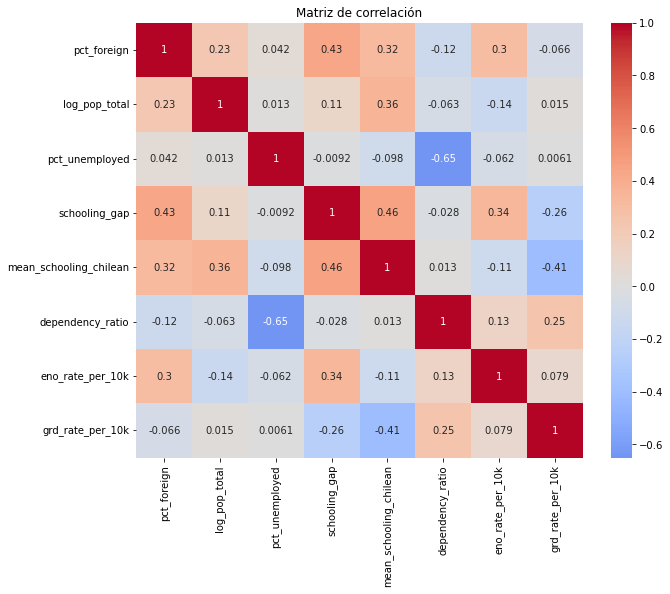

In [11]:
cols = [
    "pct_foreign",
    "log_pop_total",
    "pct_unemployed",
    "schooling_gap",
    "mean_schooling_chilean",
    "dependency_ratio",
    "eno_rate_per_10k",
    "grd_rate_per_10k"]
corr = df[cols].dropna().corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

Correlation matrix
The correlation matrix summarizes pairwise linear associations between the main demographic covariates and the health outcomes (ENO and GRD rates). Correlations are computed after removing missing values to ensure comparability across variables.

Overall, most correlations are moderate in magnitude, suggesting that no single variable perfectly explains the variation in ENO or GRD rates. The percentage of foreign population shows a positive association with ENO rates, indicating that comunas with higher shares of foreign-born residents tend to have higher notification rates. Similarly, schooling_gap is positively correlated with ENO rates, suggesting that differences in educational attainment between Chilean and foreign populations may be linked to health outcomes.

For GRD rates, the relationship appears different. mean_schooling_chilean shows a negative correlation with GRD rates, indicating that comunas with higher average schooling tend to have lower hospitalization rates. Additionally, dependency_ratio has a positive correlation with GRD rates, which is consistent with higher healthcare demand in populations with larger dependent shares (children and elderly).

Importantly, no pair of covariates shows extremely high correlation (e.g., above 0.8), which suggests that multicollinearity is unlikely to be a severe issue in the regression models. However, some moderate correlations (e.g., between schooling variables and schooling_gap) should be interpreted cautiously when estimating causal effects.

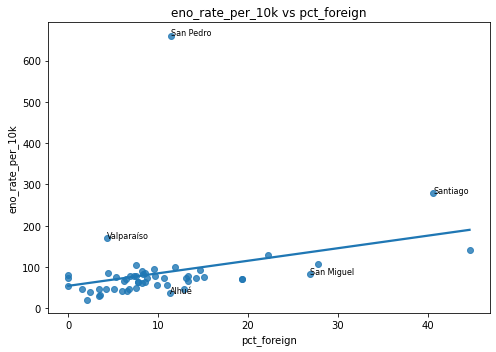

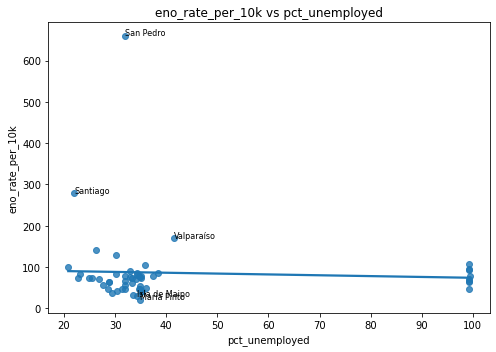

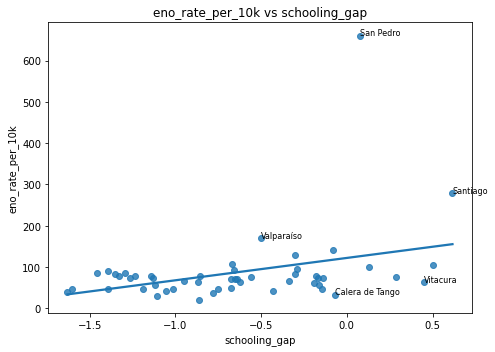

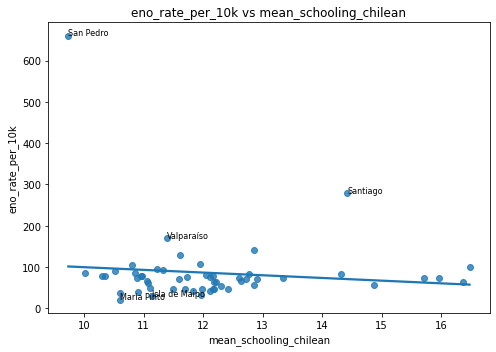

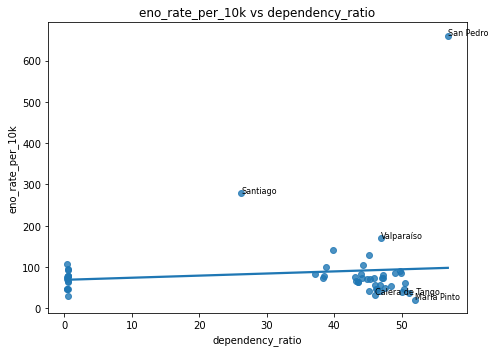

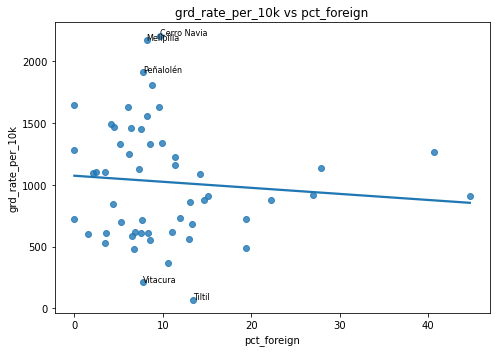

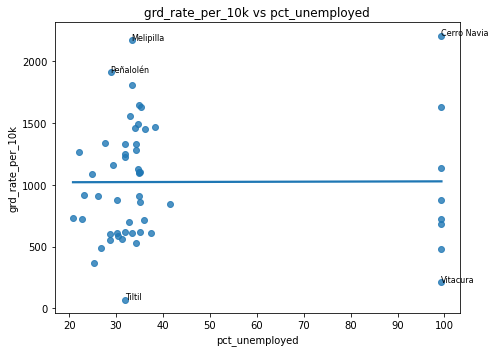

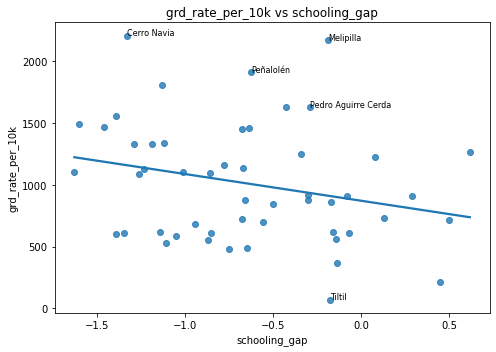

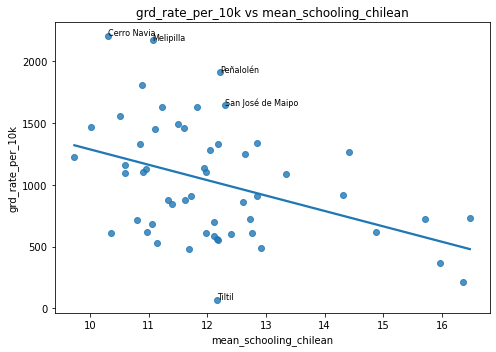

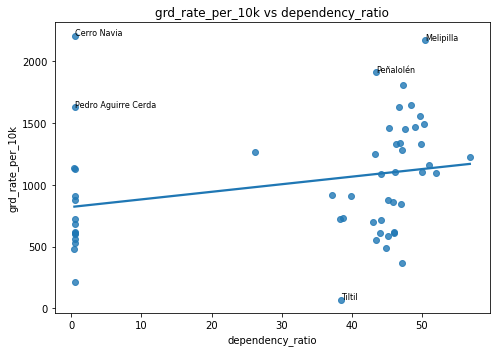

,nombre_comuna,resid
4,Cerro Navia,1383.887744
44,Melipilla,1040.154052
27,Tiltil,986.604979
23,Peñalolén,824.197593
22,Pedro Aguirre Cerda,804.846721


In [12]:
covariates = [
    "pct_foreign",
    "pct_unemployed",
    "schooling_gap",
    "mean_schooling_chilean",
    "dependency_ratio"]
outcomes = ["eno_rate_per_10k", "grd_rate_per_10k"]

for outcome in outcomes:
    for x in covariates:
        
        data = df[[x, outcome, "nombre_comuna"]].dropna().copy()

        # modelo OLS simple para residuos
        X = sm.add_constant(data[x])
        model = sm.OLS(data[outcome], X).fit()
        data["resid"] = abs(model.resid)

        # top 5 outliers
        top5 = data.nlargest(5, "resid")

        # gráfico
        plt.figure(figsize=(7,5))
        sns.regplot(data=data, x=x, y=outcome, ci=None)

        # etiquetar outliers
        for _, row in top5.iterrows():
            plt.text(row[x], row[outcome], row["nombre_comuna"], fontsize=8)

        plt.title(f"{outcome} vs {x}")
        plt.tight_layout()
        plt.show()
top5[["nombre_comuna", "resid"]]

Bivariate scatter plots and outliers

To explore the relationship between demographic covariates and health outcomes, a series of bivariate scatter plots were constructed. Each plot displays one covariate on the x-axis and one outcome variable (ENO or GRD rate per 10,000 inhabitants) on the y-axis. A simple OLS regression line was overlaid in each case to highlight the general direction of the association.

Across the ENO plots, most relationships appear relatively weak, with substantial dispersion around the fitted line. For example, the association between pct_foreign and ENO rates is slightly positive, while pct_unemployed shows little to no clear linear relationship. In contrast, schooling_gap exhibits a more noticeable positive trend, suggesting that comunas with larger differences in educational attainment between Chilean and foreign populations may experience higher notification rates. Meanwhile, mean_schooling_chilean shows a mild negative relationship, consistent with better socioeconomic conditions being associated with lower ENO incidence.

To formally identify outliers, a simple OLS model was estimated for each scatter plot and the absolute residuals were computed. The five comunas with the largest residuals were labeled directly in the plots. These observations represent cases where the actual outcome deviates significantly from the value predicted by the linear trend.

The results show that Cerro Navia, Melipilla, Tiltil, Peñalolén, and Pedro Aguirre Cerda consistently appear among the most extreme observations. Cerro Navia stands out as the largest outlier, suggesting that its ENO rate is much higher than expected given its demographic profile. Melipilla and Tiltil also show large deviations, which may be partly explained by small population sizes, making their rates more sensitive to fluctuations in case counts (small-N problem). Peñalolén and Pedro Aguirre Cerda also deviate from the general trend, potentially reflecting local differences in healthcare access, reporting practices, or population composition.

Overall, the presence of these outliers indicates that simple bivariate relationships do not fully capture the complexity of the data. This motivates the use of multivariate regression models in the following sections to better account for multiple factors simultaneously.

In [13]:
# ============================
# Variables del modelo
# ============================

df["pct_unemployed"] = 100 - df[["emp_rate_chilean", "emp_rate_foreign"]].mean(axis=1)
df["schooling_gap"] = df["mean_schooling_chilean"] - df["mean_schooling_foreign"]
df["log_pop_total"] = np.log(df["pop_total"])

covariates = [
    "pct_foreign",
    "mean_schooling_chilean",   # educación
    "pct_unemployed",           # empleo
    "dependency_ratio"          # housing/service o covariable adicional disponible
]

formula_eno = "eno_total ~ " + " + ".join(covariates)
formula_grd = "grd_total ~ " + " + ".join(covariates)

model_cols_eno = ["eno_total", "pop_total"] + covariates
model_cols_grd = ["grd_total", "pop_total"] + covariates

eno_df = df[model_cols_eno].dropna().copy()
grd_df = df[model_cols_grd].dropna().copy()

print("N ENO:", len(eno_df))
print("N GRD:", len(grd_df))

N ENO: 54
N GRD: 54


In [14]:
# ============================
# Función para tabla IRR
# ============================

def make_irr_table(model):
    conf = model.conf_int()
    out = pd.DataFrame({
        "coef": model.params,
        "std_err": model.bse,
        "z": model.tvalues,
        "p_value": model.pvalues,
        "IRR": np.exp(model.params),
        "IRR_low_95": np.exp(conf[0]),
        "IRR_high_95": np.exp(conf[1])
    })
    return out

In [15]:
poisson_eno = smf.glm(
    formula=formula_eno,
    data=eno_df,
    family=sm.families.Poisson(),
    offset=np.log(eno_df["pop_total"])
).fit()

print(poisson_eno.summary())

irr_poisson_eno = make_irr_table(poisson_eno)
irr_poisson_eno
print("Deviance:", poisson_eno.deviance)
print("Pearson chi-square:", poisson_eno.pearson_chi2)
print("AIC:", poisson_eno.aic)
dispersion_eno = poisson_eno.pearson_chi2 / poisson_eno.df_resid
print("Dispersion ENO:", dispersion_eno)

                 Generalized Linear Model Regression Results                  
Dep. Variable:              eno_total   No. Observations:                   54
Model:                            GLM   Df Residuals:                       49
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4918.3
Date:                Sun, 03 May 2026   Deviance:                       9380.8
Time:                        19:16:11   Pearson chi2:                 1.26e+04
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -4

In [16]:
nb_eno = smf.glm(
    formula=formula_eno,
    data=eno_df,
    family=sm.families.NegativeBinomial(),
    offset=np.log(eno_df["pop_total"])
).fit()

print(nb_eno.summary())

irr_nb_eno = make_irr_table(nb_eno)
irr_nb_eno

                 Generalized Linear Model Regression Results                  
Dep. Variable:              eno_total   No. Observations:                   54
Model:                            GLM   Df Residuals:                       49
Model Family:        NegativeBinomial   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -417.57
Date:                Sun, 03 May 2026   Deviance:                       13.857
Time:                        19:16:11   Pearson chi2:                     26.0
No. Iterations:                    14   Pseudo R-squ. (CS):             0.1178
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -4

,coef,std_err,z,p_value,IRR,IRR_low_95,IRR_high_95
Intercept,-4.471480,1.283587,-3.483583,0.000495,0.011430,0.000924,0.141466
pct_foreign,0.035506,0.016356,2.170770,0.029949,1.036143,1.003454,1.069898
mean_schooling_chilean,-0.088773,0.092419,-0.960554,0.336776,0.915053,0.763448,1.096764
pct_unemployed,0.001835,0.007445,0.246433,0.805347,1.001836,0.987323,1.016563
dependency_ratio,0.008573,0.008817,0.972325,0.330889,1.008610,0.991330,1.026190


In [17]:
comparison_eno = pd.DataFrame({
    "coef_poisson": poisson_eno.params,
    "p_poisson": poisson_eno.pvalues,
    "coef_nb": nb_eno.params,
    "p_nb": nb_eno.pvalues,
    "IRR_poisson": np.exp(poisson_eno.params),
    "IRR_nb": np.exp(nb_eno.params)
})

comparison_eno

,coef_poisson,p_poisson,coef_nb,p_nb,IRR_poisson,IRR_nb
Intercept,-4.868603,0.000000e+00,-4.471480,0.000495,0.007684,0.011430
pct_foreign,0.033339,0.000000e+00,0.035506,0.029949,1.033901,1.036143
mean_schooling_chilean,-0.023149,1.942570e-15,-0.088773,0.336776,0.977116,0.915053
pct_unemployed,-0.001869,6.092450e-14,0.001835,0.805347,0.998133,1.001836
dependency_ratio,0.001615,2.659555e-07,0.008573,0.330889,1.001616,1.008610


In [18]:
poisson_grd = smf.glm(
    formula=formula_grd,
    data=grd_df,
    family=sm.families.Poisson(),
    offset=np.log(grd_df["pop_total"])
).fit()

print(poisson_grd.summary())

irr_poisson_grd = make_irr_table(poisson_grd)
irr_poisson_grd
dispersion_grd = poisson_grd.pearson_chi2 / poisson_grd.df_resid
print("Dispersion GRD:", dispersion_grd)
print("Deviance GRD:", poisson_grd.deviance)
print("Pearson chi-square GRD:", poisson_grd.pearson_chi2)
print("AIC GRD:", poisson_grd.aic)

                 Generalized Linear Model Regression Results                  
Dep. Variable:              grd_total   No. Observations:                   54
Model:                            GLM   Df Residuals:                       49
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -70309.
Date:                Sun, 03 May 2026   Deviance:                   1.4003e+05
Time:                        19:16:11   Pearson chi2:                 1.29e+05
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0

In [19]:
nb_grd = smf.glm(
    formula=formula_grd,
    data=grd_df,
    family=sm.families.NegativeBinomial(),
    offset=np.log(grd_df["pop_total"])
).fit()

print(nb_grd.summary())

irr_nb_grd = make_irr_table(nb_grd)
irr_nb_grd

                 Generalized Linear Model Regression Results                  
Dep. Variable:              grd_total   No. Observations:                   54
Model:                            GLM   Df Residuals:                       49
Model Family:        NegativeBinomial   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -552.91
Date:                Sun, 03 May 2026   Deviance:                       10.914
Time:                        19:16:11   Pearson chi2:                     8.51
No. Iterations:                     8   Pseudo R-squ. (CS):            0.06590
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -1

,coef,std_err,z,p_value,IRR,IRR_low_95,IRR_high_95
Intercept,-1.102389,1.282279,-0.859711,0.389948,0.332077,0.026901,4.099361
pct_foreign,0.006814,0.016346,0.416851,0.676788,1.006837,0.975092,1.039616
mean_schooling_chilean,-0.146144,0.092330,-1.582849,0.113456,0.864033,0.721007,1.035432
pct_unemployed,0.003481,0.007438,0.467996,0.639787,1.003487,0.988964,1.018224
dependency_ratio,0.010433,0.008804,1.185007,0.236015,1.010488,0.993200,1.028076


In [20]:
comparison_grd = pd.DataFrame({
    "coef_poisson": poisson_grd.params,
    "p_poisson": poisson_grd.pvalues,
    "coef_nb": nb_grd.params,
    "p_nb": nb_grd.pvalues,
    "IRR_poisson": np.exp(poisson_grd.params),
    "IRR_nb": np.exp(nb_grd.params)
})

comparison_grd

,coef_poisson,p_poisson,coef_nb,p_nb,IRR_poisson,IRR_nb
Intercept,-0.957149,0.000000e+00,-1.102389,0.389948,0.383986,0.332077
pct_foreign,0.011229,0.000000e+00,0.006814,0.676788,1.011292,1.006837
mean_schooling_chilean,-0.150711,0.000000e+00,-0.146144,0.113456,0.860096,0.864033
pct_unemployed,0.002037,1.170991e-160,0.003481,0.639787,1.002039,1.003487
dependency_ratio,0.009166,0.000000e+00,0.010433,0.236015,1.009209,1.010488


Poisson and Negative Binomial Regression Results

To model ENO notifications at the comuna level, a log-linear count model was estimated using a Poisson specification with a population offset. This ensures that the model captures rates rather than raw counts, adjusting appropriately for differences in comuna size.

The Poisson regression results indicate that several covariates are statistically significant. In particular, pct_foreign shows a positive and highly significant association with ENO counts. The estimated coefficient (0.0333) corresponds to an incidence rate ratio (IRR) of approximately 1.034, implying that a one percentage point increase in the foreign population share is associated with a 3.4% increase in ENO notifications, holding other variables constant. Conversely, mean_schooling_chilean has a negative and significant effect, suggesting that higher average education levels are associated with lower ENO rates. The unemployment rate (pct_unemployed) also shows a small but statistically significant negative coefficient, while dependency_ratio is positively associated with ENO counts.

However, the dispersion statistic for the Poisson model is extremely large (approximately 256), far exceeding the benchmark value of 1. This clearly indicates severe overdispersion, meaning that the variance of ENO counts is much larger than the mean. As a result, the Poisson model underestimates standard errors and overstates statistical significance.

To address this issue, the model was re-estimated using a Negative Binomial specification, which explicitly allows for overdispersion. The Negative Binomial results differ substantially from the Poisson ones. While pct_foreign remains statistically significant (p ≈ 0.03) with a similar magnitude (IRR ≈ 1.036), all other covariates lose statistical significance. For example, mean_schooling_chilean, which was highly significant under the Poisson model, becomes non-significant (p ≈ 0.34) under the Negative Binomial model. Similarly, pct_unemployed and dependency_ratio are no longer statistically distinguishable from zero.

These differences are critical: they show that the apparent significance of several predictors in the Poisson model was driven by underestimated standard errors due to overdispersion. The Negative Binomial model provides more reliable inference by correcting this issue.

Based on these results, the Negative Binomial specification is clearly preferred as the primary model. It produces more conservative and credible estimates, and only pct_foreign remains a robust predictor of ENO notifications across specifications.

---
GRD Model Results

A similar modeling strategy was applied to GRD hospitalizations. The Poisson model again shows multiple statistically significant coefficients, including positive effects for pct_foreign, pct_unemployed, and dependency_ratio, and a negative effect for mean_schooling_chilean.

However, the dispersion statistic for the GRD Poisson model is even larger (approximately 2639), indicating extreme overdispersion. This strongly violates the assumptions of the Poisson model.

When the model is re-estimated using a Negative Binomial specification, all covariates lose statistical significance. In particular, pct_foreign, which appeared strongly significant in the Poisson model, becomes non-significant (p ≈ 0.68). The same occurs for all other predictors.

Given this evidence, the Negative Binomial model is again the appropriate specification. The results suggest that, once overdispersion is properly accounted for, there is no strong statistical evidence that the included covariates explain variation in GRD hospitalizations across comunas.

Overall, these findings highlight the importance of testing for overdispersion in count models. Relying on Poisson results alone would have led to misleading conclusions about the determinants of both ENO and GRD outcomes.

In [21]:
ols_df = df[[
    "grd_mean_los",
    "pct_foreign",
    "pct_unemployed",
    "schooling_gap",
    "dependency_ratio"
]].dropna()

ols = smf.ols(
    formula="grd_mean_los ~ pct_foreign + pct_unemployed + schooling_gap + dependency_ratio",
    data=ols_df
).fit(cov_type="HC1")

print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:           grd_mean_los   R-squared:                       0.168
Model:                            OLS   Adj. R-squared:                  0.096
Method:                 Least Squares   F-statistic:                     3.867
Date:                Sun, 03 May 2026   Prob (F-statistic):            0.00863
Time:                        19:16:11   Log-Likelihood:                -48.494
No. Observations:                  51   AIC:                             107.0
Df Residuals:                      46   BIC:                             116.6
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            6.1748      0.622  

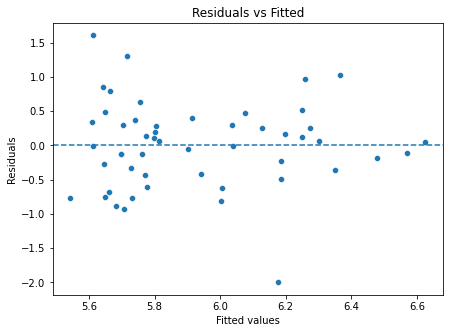

In [22]:
ols_df["fitted"] = ols.fittedvalues
ols_df["resid"] = ols.resid

plt.figure(figsize=(7,5))
sns.scatterplot(data=ols_df, x="fitted", y="resid")
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Fitted")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

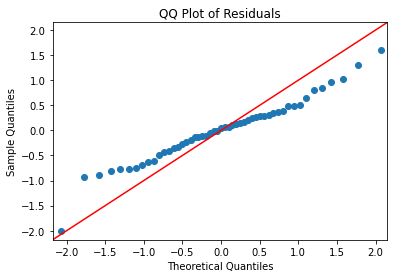

In [23]:
sm.qqplot(ols.resid, line="45")
plt.title("QQ Plot of Residuals")
plt.show()

Part 3: Continuous-Outcome Regression

3.1 Selection of the outcome variable
For the continuous-outcome analysis, we focus on `grd_mean_los` (mean length of stay in days) at the comuna level.
This variable is of particular relevance from a policy and management perspective, as it captures an important dimension of hospital performance and resource utilization. Length of stay (LOS) reflects not only the clinical complexity of cases, but also system efficiency, discharge practices, and potential barriers in access to post-hospital care. Therefore, analyzing its variation across comunas provides insight into structural differences in healthcare demand and system response.

3.2 Linear regression model
An Ordinary Least Squares (OLS) regression model is estimated to examine the association between mean length of stay and a set of socio-demographic covariates previously used in Part 2: pct_foreign, pct_unemployed, schooling_gap, and dependency_ratio.
Given the cross-sectional nature of the data and the potential presence of heteroskedasticity, the model is estimated using robust standard errors (HC1), ensuring more reliable statistical inference.

Model performance
The estimated model yields an R² of 0.168 and an adjusted R² of 0.096. These values indicate that the model explains a limited, yet non-negligible portion of the variation in LOS across comunas. This level of explanatory power is consistent with expectations in aggregate, cross-sectional analyses, where unobserved heterogeneity often plays a significant role.
Importantly, the model is jointly statistically significant (F-test p-value < 0.01), suggesting that the set of covariates, when considered together, contributes meaningfully to explaining variation in the outcome.

Interpretation of key coefficients
The proportion of foreign population (pct_foreign) emerges as the only statistically significant predictor at conventional levels. The positive coefficient indicates that comunas with a higher share of foreign residents tend to exhibit longer average hospital stays.
From an interpretative standpoint, this relationship may capture a range of underlying mechanisms, including differences in access to timely care, variations in case severity at admission, or structural barriers within the healthcare system that affect specific population groups. While the magnitude of the effect is modest, its statistical significance suggests that demographic composition is a relevant factor in understanding LOS variability.
In contrast, the remaining covariates — pct_unemployed, schooling_gap, and dependency_ratio — do not show statistically significant associations with LOS in this specification. This does not necessarily imply that these factors are irrelevant, but rather that their effects may be mediated through other unobserved variables or that their impact is not linear or sufficiently strong to be detected within this model.

3.3 Model diagnostics
To assess the validity of the OLS assumptions, standard diagnostic tools were examined.
The residuals versus fitted values plot shows that residuals are generally centered around zero without a clear systematic pattern. This supports the assumption of linearity and suggests that the model is not suffering from major functional form misspecification. However, there is some variation in the spread of residuals across fitted values, indicating the presence of mild heteroskedasticity. This issue is appropriately addressed through the use of robust standard errors.
The QQ plot of residuals reveals moderate deviations from normality, particularly in the tails. This pattern suggests the presence of outliers or heavier-than-normal tails in the residual distribution. While such deviations are not uncommon in applied settings, they should be acknowledged when interpreting inference.

Assessment of model assumptions
Overall, the OLS assumptions appear reasonably satisfied. Linearity holds, and there are no strong indications of model misspecification. Although mild heteroskedasticity and slight deviations from normality are present, these issues are not severe and are mitigated through the use of robust estimation techniques.

Potential extensions
From a methodological perspective, several extensions could be considered to further improve the model. These include applying a transformation to the dependent variable (such as a logarithmic transformation), exploring non-linear relationships, or implementing alternative estimation methods such as robust regression.
Additionally, incorporating further covariates capturing healthcare supply, infrastructure, or epidemiological conditions could enhance explanatory power.

Conclusion
The OLS analysis provides a structured and interpretable framework to examine the determinants of hospital length of stay at the comuna level. While the overall explanatory power is limited, the results highlight the relevance of demographic composition — particularly the proportion of foreign population — in explaining variations in LOS.
The diagnostic assessment suggests that the model is broadly well specified, and the findings should be interpreted as indicative rather than causal. Overall, the analysis underscores the complexity of healthcare utilization patterns and the importance of considering both observed and unobserved factors in understanding system performance.

# Part 4: Ecological Fallacy

All analyses conducted in this study are ecological in nature, meaning that the unit of observation is the comuna rather than the individual. This distinction is crucial when interpreting the results, as relationships identified at the aggregate level do not necessarily translate into equivalent relationships at the individual level.

An ecological association refers to a statistical relationship observed between variables aggregated at the group level, such as the relationship between the proportion of foreign population (`pct_foreign`) and ENO notification rates (`eno_rate_per_10k`) across comunas. In contrast, an individual-level association describes how characteristics of individuals relate to outcomes measured at the same individual level. The key difference lies in the level of aggregation: ecological associations capture variation between groups, while individual-level associations capture variation within groups.

A central risk in ecological analysis is the ecological fallacy (Robinson, 1950), which occurs when one incorrectly infers individual-level relationships from group-level data. For example, in our results, the proportion of foreign population (`pct_foreign`) is positively associated with ENO notification rates in the Negative Binomial model. A misinterpretation of this finding would be to conclude that foreign-born individuals are more likely to be reported as ENO cases. This interpretation would be incorrect because the observed association may be driven by other comuna-level factors. For instance, comunas with higher foreign population shares may also have higher population density, better reporting systems, or greater access to healthcare services, all of which can increase notification rates independently of individual risk. Therefore, the estimated coefficient captures a contextual or compositional effect at the comuna level, not a causal relationship at the individual level.

Despite these limitations, ecological associations remain highly valuable for public-health planning. The positive relationship between `pct_foreign` and ENO rates can help identify comunas where public-health surveillance and intervention efforts may need to be strengthened. Even though we cannot conclude that foreign-born individuals are inherently at higher risk, the association highlights geographic areas where health outcomes differ systematically. This information can guide resource allocation, such as expanding testing capacity, improving access to healthcare services, or implementing targeted outreach programs. In this sense, ecological analysis is particularly useful for identifying patterns and prioritizing interventions at the population level.

Beyond the ecological fallacy, an additional threat to inference in this analysis is spatial autocorrelation. Comunas are not independent observational units: neighboring comunas often share similar socio-demographic characteristics, healthcare infrastructure, and epidemiological conditions. As a result, outcomes such as ENO notification rates or GRD hospitalizations may be spatially correlated, violating the standard regression assumption of independent observations. This can lead to underestimated standard errors and overstated statistical significance.

In practical terms, part of the observed association between covariates and health outcomes may be driven by geographic clustering rather than true underlying relationships. For example, comunas located within the same metropolitan area may exhibit similar healthcare access patterns or disease dynamics that are not fully captured by the included covariates.

To address these limitations in future work, one could incorporate spatial econometric methods, such as spatial lag or spatial error models, which explicitly account for geographic dependence. Alternatively, simpler approaches such as cluster-robust standard errors or regional fixed effects could be used. Incorporating spatial weights matrices would further allow for a more accurate representation of how health outcomes diffuse across neighboring comunas.

In summary, while ecological analysis provides valuable insights into patterns across comunas, its results must be interpreted with caution. The findings should not be used to make individual-level causal claims, but rather to inform population-level understanding and guide public-health decision-making.

In [24]:
# ============================================================
# PARTE 5: MAPAS SOLO REGIÓN METROPOLITANA
# ============================================================

# Modelo principal
primary_model = nb_eno   #

# Base del modelo
model_df = df[[
    "codigo_comuna",
    "nombre_comuna",
    "eno_total",
    "pop_total",
    "pct_foreign",
    "mean_schooling_chilean",
    "pct_unemployed",
    "dependency_ratio"
]].dropna().copy()

# Predicción
model_df["pred_count"] = primary_model.predict(
    model_df,
    offset=np.log(model_df["pop_total"])
)

model_df["pred_rate_per_10k"] = (
    model_df["pred_count"] / model_df["pop_total"] * 10000
)

# Residuos Pearson
model_df["pearson_resid"] = primary_model.resid_pearson

# Cargar shapefile
shp_path = "/Users/martingomez/Downloads/comunas.shp"  # ajusta ruta si corresponde
shp = gpd.read_file(shp_path)

# Limpiar nombres de columnas
shp.columns = shp.columns.str.lower()

# Renombrar código comuna
shp = shp.rename(columns={"cod_comuna": "codigo_comuna"})

# Asegurar tipos
shp["codigo_comuna"] = pd.to_numeric(shp["codigo_comuna"], errors="coerce")
shp["codregion"] = pd.to_numeric(shp["codregion"], errors="coerce")
model_df["codigo_comuna"] = pd.to_numeric(model_df["codigo_comuna"], errors="coerce")

# Merge espacial
map_df = shp.merge(
    model_df[[
        "codigo_comuna",
        "nombre_comuna",
        "pred_rate_per_10k",
        "pearson_resid"
    ]],
    on="codigo_comuna",
    how="left"
)

# Filtrar solo Región Metropolitana
map_df_rm = map_df[map_df["codregion"] == 13].copy()

print("Shape RM:", map_df_rm.shape)
print("Comunas RM sin match:", map_df_rm["nombre_comuna"].isna().sum())

Shape RM: (55, 15)
Comunas RM sin match: 3


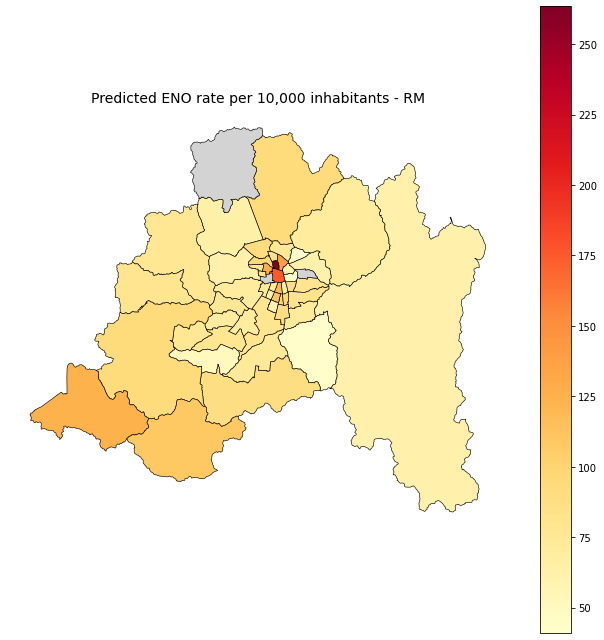

In [25]:
# ============================================================
# 5.1 MAPA: TASA PREDICHA ENO POR 10.000 HABITANTES
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(9, 9))

map_df_rm.plot(
    column="pred_rate_per_10k",
    cmap="YlOrRd",
    linewidth=0.6,
    edgecolor="black",
    legend=True,
    missing_kwds={
        "color": "lightgrey",
        "label": "Sin datos"
    },
    ax=ax
)

ax.set_title("Predicted ENO rate per 10,000 inhabitants - RM", fontsize=14)
ax.axis("off")

plt.tight_layout()
plt.show()

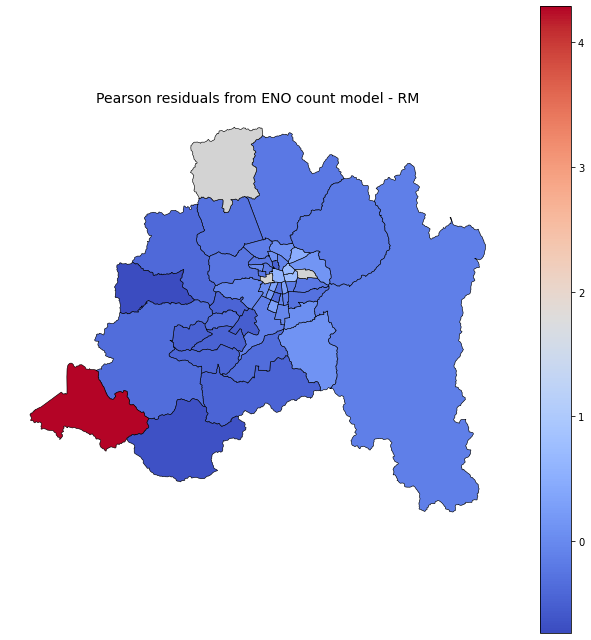

In [26]:
# ============================================================
# 5.2 MAPA: RESIDUOS PEARSON
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(9, 9))

map_df_rm.plot(
    column="pearson_resid",
    cmap="coolwarm",
    linewidth=0.6,
    edgecolor="black",
    legend=True,
    missing_kwds={
        "color": "lightgrey",
        "label": "Sin datos"
    },
    ax=ax
)

ax.set_title("Pearson residuals from ENO count model - RM", fontsize=14)
ax.axis("off")

plt.tight_layout()
plt.show()

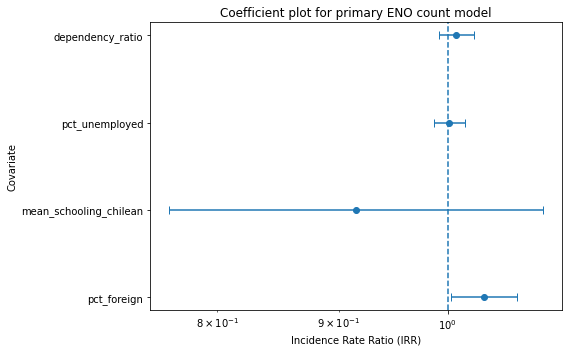

In [27]:
# ============================================================
# 5.3 COEFFICIENT PLOT / FOREST PLOT
# ============================================================

params = primary_model.params
conf = primary_model.conf_int()

coef_df = pd.DataFrame({
    "variable": params.index,
    "IRR": np.exp(params),
    "IRR_low_95": np.exp(conf[0]),
    "IRR_high_95": np.exp(conf[1])
})

coef_df = coef_df[coef_df["variable"] != "Intercept"]

plt.figure(figsize=(8, 5))

plt.errorbar(
    coef_df["IRR"],
    coef_df["variable"],
    xerr=[
        coef_df["IRR"] - coef_df["IRR_low_95"],
        coef_df["IRR_high_95"] - coef_df["IRR"]
    ],
    fmt="o",
    capsize=4
)

plt.axvline(1, linestyle="--")
plt.xscale("log")

plt.xlabel("Incidence Rate Ratio (IRR)")
plt.ylabel("Covariate")
plt.title("Coefficient plot for primary ENO count model")

plt.tight_layout()
plt.show()

# Part 5: Spatial Visualization of Model Output

## 5.1 Predicted-rate map

Using the preferred count model (Negative Binomial), the predicted ENO notification rate per 10,000 inhabitants was computed for each comuna and visualized through a choropleth map.

The resulting spatial distribution shows a clear concentration of higher predicted notification rates in central comunas of the Metropolitan Region, while peripheral comunas tend to exhibit lower predicted values. This pattern is consistent with the concentration of healthcare infrastructure, reporting capacity, and population density in urban cores.

The use of a sequential color scale effectively highlights gradients in predicted risk, allowing for intuitive identification of high- and low-rate areas. Overall, the map provides a clear spatial representation of the model’s fitted values and helps contextualize the distribution of ENO notifications across the region.

## 5.2 Residual map

Standardized Pearson residuals from the Negative Binomial model were mapped using a diverging color palette centered at zero. This allows for a clear distinction between over-predicted and under-predicted comunas.

The residual map indicates that most comunas exhibit small residuals, suggesting a generally good model fit across the region. However, a small number of comunas stand out with large positive residuals, particularly in the western part of the region (e.g., Melipilla), indicating that the observed ENO rates are significantly higher than predicted by the model. These areas may reflect unobserved local factors such as under-measured exposure risks, reporting differences, or localized outbreaks.

Conversely, several comunas display moderately negative residuals, implying that the model overestimates ENO notification rates in those locations. These discrepancies suggest that additional covariates or spatial structure may be needed to fully capture the variation in the data.

## 5.3 Coefficient plot

The coefficient plot (forest plot) summarizes the estimated effects of the covariates in the Negative Binomial model, expressed as Incidence Rate Ratios (IRR) with corresponding 95% confidence intervals on a logarithmic scale.

The results indicate that `pct_foreign` is positively associated with ENO notification rates, with an IRR greater than one and a confidence interval that does not cross the null value, suggesting a statistically significant association. In contrast, `mean_schooling_chilean` shows an IRR below one, although with wider uncertainty, indicating a potential negative association with ENO rates.

The variables `pct_unemployed` and `dependency_ratio` are close to the null (IRR ≈ 1), with confidence intervals overlapping the reference line, suggesting weak or statistically insignificant associations in this model specification.

The coefficient plot provides a compact and interpretable summary of effect sizes and uncertainty, highlighting which covariates are most strongly associated with ENO notification rates while clearly indicating statistical significance relative to the null benchmark (IRR = 1).

# Part 6: Integrated Synthesis

The three stages of this analysis—demographic characterization, health outcomes, and cross-dataset modeling—together provide a coherent picture of how population structure and health outcomes interact across comunas in the Región Metropolitana (RM). Rather than considering each dataset in isolation, the integrated approach allows us to identify systematic patterns that would not be fully visible otherwise.

From a demographic perspective (Tarea 1), the RM exhibits a clear gradient across comunas that can be interpreted as a socio-economic and structural axis of variation. Comunas differ substantially in terms of educational attainment (`mean_schooling_chilean`), proportion of foreign population (`pct_foreign`), unemployment (`pct_unemployed`), and dependency ratios. In general, central and more urbanized comunas tend to display higher levels of education and greater population density, while peripheral comunas show lower educational attainment and different labor market conditions. This axis effectively captures a transition from more advantaged, service-rich comunas to more peripheral and structurally constrained ones.

The health landscape (Tarea 2) partially aligns with this demographic gradient, but not in a perfectly linear way. ENO notification rates (`eno_rate_per_10k`) tend to be higher in more urban and central comunas, which is consistent with both higher exposure and stronger reporting systems. Similarly, GRD indicators show spatial concentration patterns that reflect the structure of the healthcare system. However, there are also important mismatches: some comunas with relatively moderate demographic indicators exhibit unexpectedly high notification rates, while others with less favorable socio-economic conditions do not show proportionally worse outcomes. These discrepancies suggest that health outcomes are influenced not only by demographic composition but also by factors such as healthcare access, reporting practices, and localized epidemiological dynamics.

The cross-dataset models (Tarea 3) add substantial value beyond simple descriptive statistics or correlation matrices. While the correlation matrix suggested relatively weak pairwise relationships between several variables, the count models—particularly the Negative Binomial specification—revealed more nuanced associations when controlling for multiple covariates simultaneously. For example, `pct_foreign` shows a positive and statistically significant association with ENO notification rates (IRR > 1), even after adjusting for education, unemployment, and dependency structure. This relationship is not immediately evident from the correlation matrix alone, where the pairwise correlation is modest.

At the same time, other variables such as `pct_unemployed` and `dependency_ratio` appear less relevant once included in a multivariate framework, with incidence rate ratios close to one and confidence intervals overlapping the null. This highlights the importance of multivariate modeling in disentangling overlapping effects that cannot be isolated through bivariate analysis.

Importantly, the modeling stage also revealed strong evidence of overdispersion in the ENO count data, as reflected in the large dispersion statistics from the Poisson model. This justified the use of the Negative Binomial model and underscores how model diagnostics can fundamentally change the interpretation of results. Relying on the Poisson specification alone would have led to misleading inferences regarding statistical significance.

The spatial visualization of model outputs further reinforces these findings. The predicted-rate map shows a concentration of higher ENO rates in central comunas, consistent with both demographic patterns and healthcare system structure. Meanwhile, the residual map highlights specific comunas—particularly in the western periphery—that are not well explained by the model, suggesting the presence of unobserved local factors. These spatial mismatches would not be detectable from tabular results alone.

In summary, the integrated analysis shows that demographic structure provides a useful but incomplete explanation of health outcomes across comunas in the RM. Health patterns broadly follow the socio-demographic gradient but are also shaped by institutional, spatial, and reporting dynamics. The combination of descriptive analysis, statistical modeling, and spatial visualization is therefore essential to obtain a more complete and policy-relevant understanding of the data.